# Demo **Paraphrasing**

Our imposter approach needs models to reword an original text keeping the same meaning.
Ideally, we want to model the way texts originated.
This is dependent on the text's genre, i.e. a student essay originates from a task description and a list of URLs while a new article originates from a list of additional sources or from spectating an event.
We implemented both a naive approach to rewording a text and a more sophisticated one:
- given a prompt and a text, the naive approach uses a language model to paraphrase the text
- given a prompt and a text LLM A is used to extract the text's genre, tone and summary of bullet points, then LLM B is used to reword the text in the same genre and tone based on the summary of bullet points

In [1]:
from pathlib import Path
import os
import textwrap
import sys
# Add the root of the project to Python path
sys.path.append(os.path.abspath(".."))
from config import CONFIG
from genai_detection.paraphrasing.paraphraser import T5ChatGPTParaphraser, T5GooglePAWSParaphraser, BlabladorParaphraser, BulletPointParaphraser, OllamaParaphraser, ParaphrasingEvaluator, TaskParaphraser, TopicParaphraser, TitleParaphraser

/Users/klara/Library/Caches/pypoetry/virtualenvs/generative-ai-detection-PkLo9Jli-py3.11/lib/python3.11/site-packages/pyemd/__init__.py:74: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from .emd import emd, emd_with_flow, emd_samples
[nltk_data] Downloading package wordnet to /Users/klara/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Original text
We use a CNN news article from 23.06.2025 as an example.

In [2]:
path2datasets = Path(os.getcwd()).resolve().parent / "data" / "datasets" / "custom_texts"
data_category = "News" # This is used for plot titles in the notebook
path2results = Path(os.getcwd()).resolve().parent / CONFIG.SAVE_PATH / "paraphrasing"
assert path2datasets.exists(), f"Path to datasets {path2datasets} does not exist."
# file_name = "cnn_230625"    # USA attacks Iran
file_name = "cnn_040725"    # Dalai Lama
original_text = open(path2datasets / f"{file_name}.txt").read()

print(textwrap.fill(original_text, width=80))

  For much of the past century, the Dalai Lama has been the living embodiment of
Tibet’s struggle for greater freedoms under Chinese Communist Party rule,
sustaining the cause from exile even as an increasingly powerful Beijing has
become ever more assertive in suppressing it.  As his 90th birthday approaches
this Sunday, the spiritual leader for millions of followers of Tibetan Buddhism
worldwide is bracing for a final showdown with Beijing: the battle over who will
control his reincarnation.  On Wednesday, the Dalai Lama announced that he will
have a successor after his death, and that his office will have the sole
authority to identify his reincarnation.  “I am affirming that the institution
of the Dalai Lama will continue,” the Nobel Peace laureate said in a video
message to religious elders gathering in Dharamshala, India, where he has found
refuge since Chinese communist troops put down an armed uprising in his
mountainous homeland in 1959.  The cycle of rebirth lies at the core 

## Naive Approach

In [3]:
paraphrasers = {
                'T5_ChatGPT': T5ChatGPTParaphraser(), 
                'T5_Google_PAWS': T5GooglePAWSParaphraser(), 
                'Blablador': BlabladorParaphraser(model_id="1 - Llama3 405 the best general model and big context size"), 
                'Ollama': OllamaParaphraser(model_id="default:latest")
                }
if 'Blablador' in paraphrasers.keys():
    print('Available Blablador models:\n', paraphrasers['Blablador']._get_available_models(verbose=False))

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Available Blablador models:
 ['1 - Llama3 405 the best general model and big context size', '1 - Ministral 8b - the fast model', '10 Mistral-Nemo-Instruct-2407 - Our fast-experimental - with a large context size', '11 - TrustLLM preview 2', '2 - Qwen3 30B A3B - a reasoning model from Alibaba from April 2025', '2 - QwenLong L1 32B - A long context reasoning model from 28.05.2025', '3 - DeepCoder-14B-Preview - the code model from 09.04.2025', '5 - GritLM-7B - For Chat AND Text Embeddings', 'alias-code', 'alias-embeddings', 'alias-fast', 'alias-fast-experimental', 'alias-large', 'alias-llama3-huge', 'alias-trustllm', 'gpt-3.5-turbo', 'text-davinci-003', 'text-embedding-ada-002']


In [4]:
n_responses = 1  # number of paraphrases to generate
max_length = 512  # Maximum length of the generated paraphrase
temperature = 0.7  # Controls the randomness of the output. Lower values make the output more deterministic.

prompts = [
        "Paraphrase the following text and output only the paraphrased version:",
        "First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts):",
        "Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.",
        "Paraphrase the sentence using the same tone as the original with approximately the same number of words:",
        "Paraphrase this sentence. Do not change the meaning, but use different words and structure. Output only the paraphrased sentence:"
        ]

In [5]:
# for paraphraser_name, paraphraser in paraphrasers.items():
#     print(f"\n{'='*40}")
#     print(f"\nUsing paraphraser: {paraphraser_name}")
#     for prompt in prompts:
#         print(f"\nPrompt: {prompt}")
#         paraphrases = paraphraser.paraphrase(original_text, 
#                                              n_responses=n_responses, 
#                                              max_length=max_length, 
#                                              temperature=temperature, 
#                                              prompt=prompt)
#         for i, paraphrase in enumerate(paraphrases):
#             print(f"Paraphrase {i+1}: {textwrap.fill(paraphrase, width=80)}")

## Bullet Point Approach

Ollama models are by far the best ones for extracting the genre, tone and summary of bullet points and returning them in a structured way.
Hence, we use the Ollama model as the text extractor and any other model as the text generator.

In [6]:
models = {'text_extractor': {'name':'Ollama-latest', 'model':OllamaParaphraser(model_id="default:latest")},
          'text_generator': {'name':'Ollama-latest', 'model':OllamaParaphraser(model_id="default:latest")}}
            #'text_generator': {'name':'Blablador-Ministral8b', 'model':BlabladorParaphraser(model_id="1 - Ministral 8b - the fast model")}}
bullet_point_paraphraser = BulletPointParaphraser(text_extractor=models["text_extractor"]['model'], text_generator=models["text_generator"]['model'])
# paraphrases = bullet_point_paraphraser.paraphrase(
#     text=original_text, prompt=None, n_responses=n_responses, max_length=max_length)
# for i, paraphrase in enumerate(paraphrases):
#     print(f"Paraphrase {i+1}:\n{paraphrase}\n")
    # save to file
    # with open(path2datasets / f"paraphrase_{file_name}_e={models["text_extractor"]['name']}_g={models["text_generator"]['name']}_{i+1}.txt", "w") as f:
    #     f.write(paraphrase)

## Task Paraphraser
The task paraphraser extracts the task, tone and genre from the text and then generates a paraphrase based on this information.

In [7]:
task_paraphraser = TaskParaphraser(text_extractor=models["text_extractor"]['model'], text_generator=models["text_generator"]['model'])
# paraphrases = task_paraphraser.paraphrase(
#     text=original_text, prompt=None, n_responses=n_responses, max_length=max_length)
# for i, paraphrase in enumerate(paraphrases):
#     print(f"Paraphrase {i+1}:\n{paraphrase}\n")

## Topic Paraphraser
The topic paraphraser extracts the topic, tone and genre from the text and then generates a paraphrase based on this information.

In [8]:
topic_paraphraser = TopicParaphraser(text_extractor=models["text_extractor"]['model'], text_generator=models["text_generator"]['model'])
# paraphrases = topic_paraphraser.paraphrase(
#     text=original_text, prompt=None, n_responses=n_responses, max_length=max_length)
# for i, paraphrase in enumerate(paraphrases):
#     print(f"Paraphrase {i+1}:\n{paraphrase}\n")

## Title Paraphraser
The title paraphraser extracts the title, tone and genre from the text and then generates a paraphrase based on this information.

In [9]:
title_paraphraser = TitleParaphraser(text_extractor=models["text_extractor"]['model'], text_generator=models["text_generator"]['model'])
# paraphrases = title_paraphraser.paraphrase(
#     text=original_text, prompt=None, n_responses=n_responses, max_length=max_length)
# for i, paraphrase in enumerate(paraphrases):
#     print(f"Paraphrase {i+1}:\n{paraphrase}\n")

## Evaluating the Approaches

In [10]:
paraphrasers.update({'BulletPoint': bullet_point_paraphraser, 'Task': task_paraphraser, 'Topic': topic_paraphraser, 'Title': title_paraphraser})
paraphrase_evaluator = ParaphrasingEvaluator(paraphrasers=paraphrasers, prompts=prompts, original_text=original_text, n_responses=n_responses, max_length=max_length, temperature=temperature)
df = paraphrase_evaluator.evaluate()
df

Evaluating Paraphrasers:   0%|          | 0/40 [00:00<?, ?it/s]

[DEBUG] Using paraphraser 'T5_ChatGPT' with prompt 'Paraphrase the following text and output only the paraphrased version:'


Evaluating Paraphrasers:   2%|▎         | 1/40 [00:17<11:20, 17.44s/it]

[DEBUG] Using paraphraser 'T5_ChatGPT' with prompt 'First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts):'


Evaluating Paraphrasers:   5%|▌         | 2/40 [00:24<07:01, 11.08s/it]

...

Evaluating Paraphrasers:  78%|███████▊  | 31/40 [08:39<02:15, 15.02s/it]

[DEBUG] Using paraphraser 'Title' with prompt 'None'

[DEBUG] Extracted title, tone, genre, time period, and register: {'title': 'Dalai Lama s Reincarnation Battle Looms', 'tone': 'neutral/informative', 'time_period': 'recent/past century', 'language_register': 'formal/academic', 'genre': 'news/journalistic'}



Evaluating Paraphrasers: 100%|██████████| 40/40 [09:11<00:00, 13.79s/it]

Results saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_results_comparison_temp0.7_maxLength512.csv


,model,prompt,parameters,original_text,paraphrased_text,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,bertscore_hash,sem_sim_avg,syn_sim_avg,gohsen_delta
0,T5_ChatGPT,Paraphrase the following text and output only ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","in the last century, the dalai lama has been t...",4.005616e-10,0.020893,0.071313,0.039024,0.064830,0.064830,0.865510,0.689394,0.767479,0.094259,0.841654,distilbert-base-uncased_L5_no-idf_version=0.3....,0.651659,0.045381,0.606279
1,T5_ChatGPT,"First, extract bullet points capturing the mai...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...","in recent times, the dalai lama has emerged as...",2.712650e-09,0.022775,0.070853,0.022617,0.041868,0.041868,0.813101,0.677040,0.738859,0.102585,0.822779,distilbert-base-uncased_L5_no-idf_version=0.3....,0.630873,0.037574,0.593299
2,T5_ChatGPT,Paraphrase the sentence by first identifying t...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of dismantling chinese ...,1.560457e-13,0.014264,0.052459,0.019737,0.045902,0.045902,0.837352,0.670556,0.744729,0.072843,0.832798,distilbert-base-uncased_L5_no-idf_version=0.3....,0.631655,0.032787,0.598869
3,T5_ChatGPT,Paraphrase the sentence using the same tone as...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political instabilit...,1.064045e-10,0.018047,0.058442,0.019544,0.048701,0.048701,0.814106,0.664090,0.731486,0.087879,0.804846,distilbert-base-uncased_L5_no-idf_version=0.3....,0.620481,0.035714,0.584767
4,T5_ChatGPT,Paraphrase this sentence. Do not change the me...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",despite the challenges of political instabilit...,1.064045e-10,0.018047,0.058442,0.019544,0.048701,0.048701,0.814106,0.664090,0.731486,0.087879,0.804846,distilbert-base-uncased_L5_no-idf_version=0.3....,0.620481,0.035714,0.584767
5,T5_Google_PAWS,Paraphrase the following text and output only ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",the reincarnation of the current dalai lama is...,2.680305e-04,0.074124,0.187879,0.136778,0.142424,0.142424,0.877150,0.741309,0.803529,0.153354,0.913667,distilbert-base-uncased_L5_no-idf_version=0.3....,0.697802,0.110190,0.587611
6,T5_Google_PAWS,"First, extract bullet points capturing the mai...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",the former dalai lama has been the living embo...,5.000661e-04,0.078580,0.205749,0.160850,0.193646,0.193646,0.892653,0.740584,0.809539,0.157238,0.849869,distilbert-base-uncased_L5_no-idf_version=0.3....,0.689976,0.133298,0.556678
7,T5_Google_PAWS,Paraphrase the sentence by first identifying t...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",the dalai lama declared in his new memoir on w...,2.508414e-04,0.090331,0.197869,0.131298,0.155251,0.155251,0.892870,0.742436,0.810734,0.138009,0.866254,distilbert-base-uncased_L5_no-idf_version=0.3....,0.690060,0.117790,0.572270
8,T5_Google_PAWS,Paraphrase the sentence using the same tone as...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h...",in a video message to religious elders gatheri...,4.238810e-04,0.082311,0.200000,0.170213,0.163636,0.163636,0.917344,0.746360,0.823066,0.135092,0.892548,distilbert-base-uncased_L5_no-idf_version=0.3....,0.702882,0.121353,0.581529
9,T5_Google_PAWS,Paraphrase this sentence. Do not change the me...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","for much of the past century, the dalai lama h..."

In [11]:
df['paraphrased_text'].values

array(['in the last century, the dalai lama has been the embodiment of tibetan buddhism, with his followers facing a difficult choice of who will control their destiny.',
       'in recent times, the dalai lama has emerged as a key figure in the struggle for freedom from china, with his powerful beijing exerting greater influence than any other political force.',
       'despite the challenges of dismantling chinese rule, the dalai lama has been an important symbol for tibetan buddhism in tibet.',
       'despite the challenges of political instability in tibet, the dalai lama has been an integral part of the struggle for freedom and independence since the 1970s.',
       'despite the challenges of political instability in tibet, the dalai lama has been an integral part of the struggle for freedom and independence since the 1970s.',
       "the reincarnation of the current dalai lama is not only pivotal to tibetan buddhism but the party's own ambition is to control the destiny of a lon

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_metrics_grouped_by_model_radar_chart_20250704_202822.png


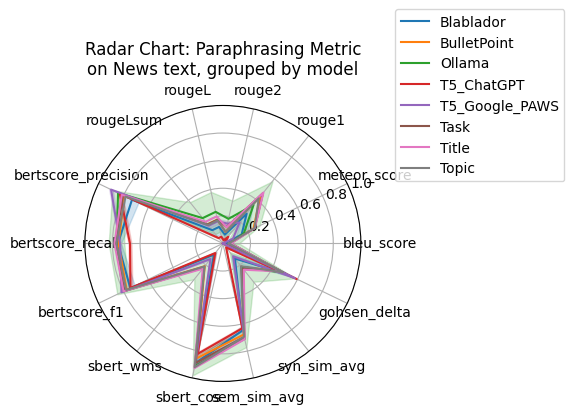

In [12]:
paraphrase_evaluator.plot_models_metrics(df=df, save_path=path2results, data_category=data_category, group_by='model')

/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser.py:827: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_metrics_grouped_by_prompt_radar_chart_20250704_202822.png


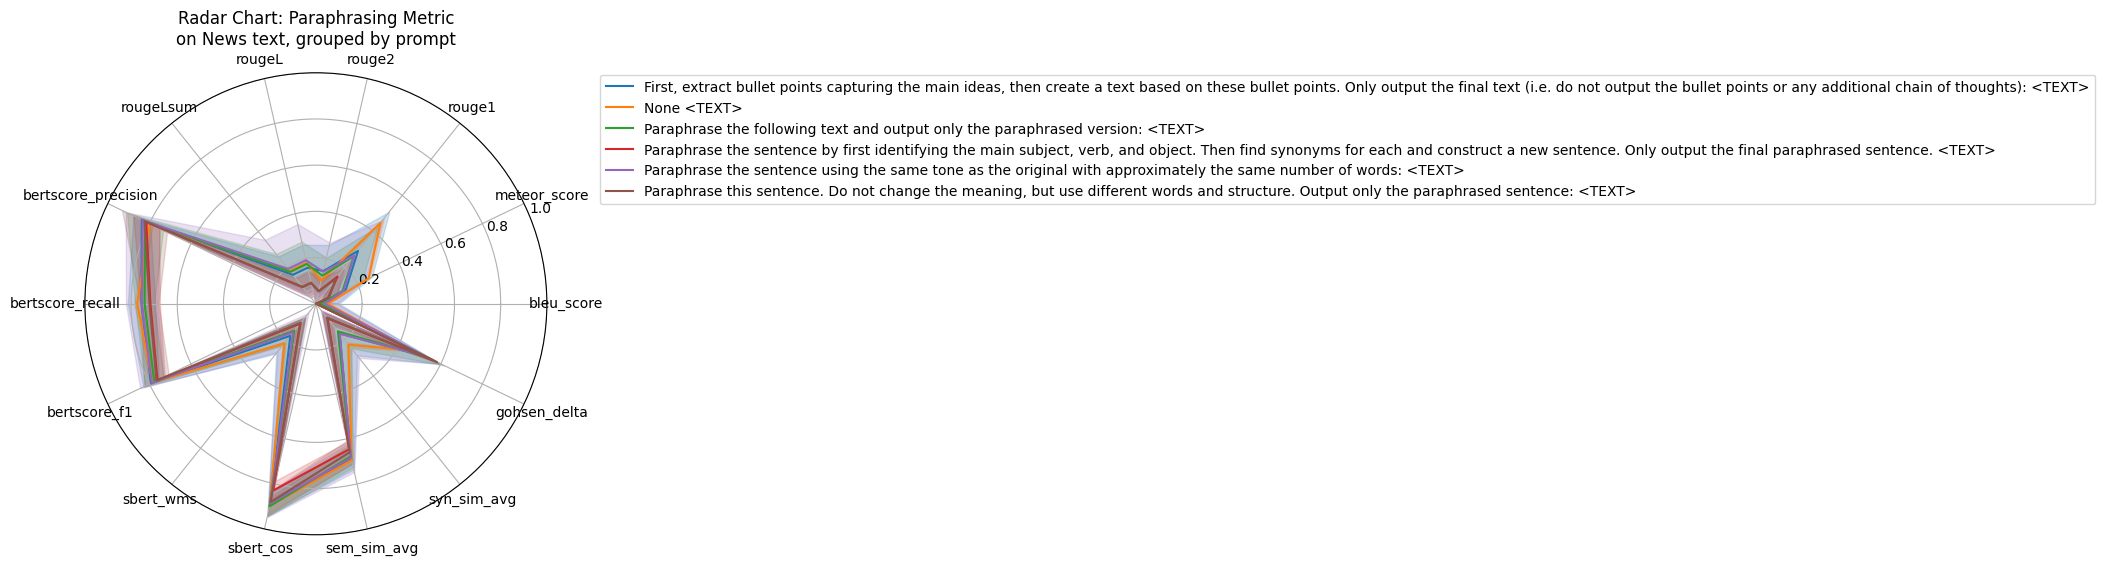

In [13]:
paraphrase_evaluator.plot_models_metrics(df=df, save_path=path2results, data_category=data_category, group_by='prompt')

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/sem_syn_scatter_grouped_by_model_20250704_202822.png


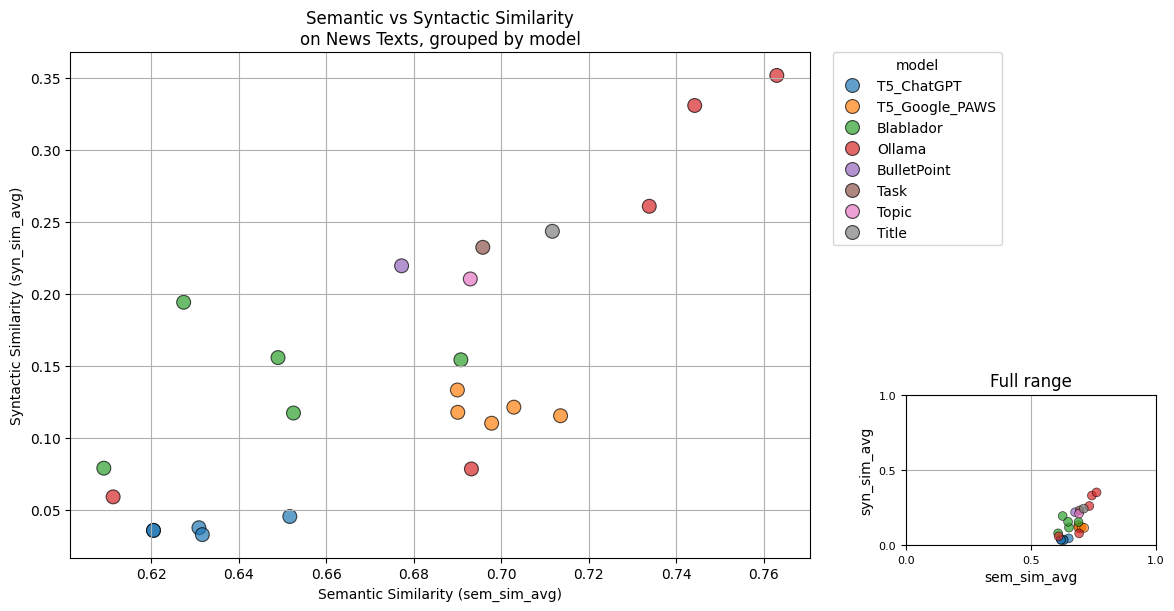

In [14]:
paraphrase_evaluator.plot_metric_scatter(df, save_path=path2results, data_category=data_category, group_by='model')

/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser.py:927: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(full_path, bbox_inches='tight')
/Users/klara/Library/Caches/pypoetry/virtualenvs/generative-ai-detection-PkLo9Jli-py3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/sem_syn_scatter_grouped_by_prompt_20250704_202822.png


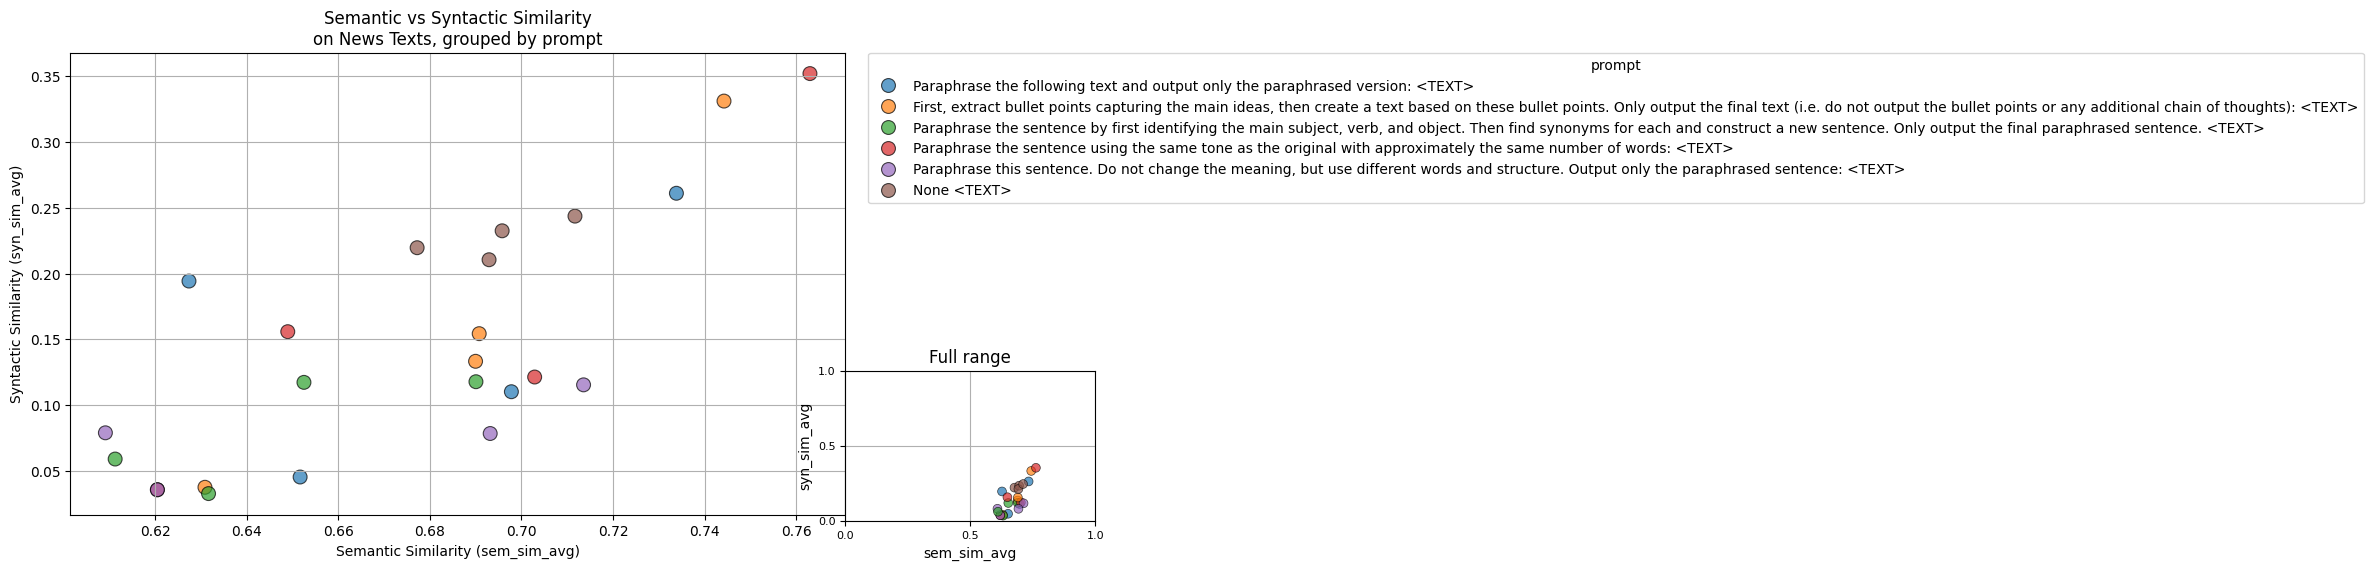

In [15]:
paraphrase_evaluator.plot_metric_scatter(df, save_path=path2results, data_category=data_category, group_by='prompt')

### Kernel Density Estimation (KDE)
- KDE estimates probability density PDF
- The y-axis is density/ concentration/ likelihood, not probability.
- Density can be greater than 1 if data are tightly clustered in a small range.
- For example, if many data points lie very close together, the curve can be sharp and tall (high density), so y-values exceed 1.
- The important property is that the **integral (area) under the curve is 1**, not that the max height is ≤1.

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/metric_distributions_grouped_by_model_20250704_202824.png


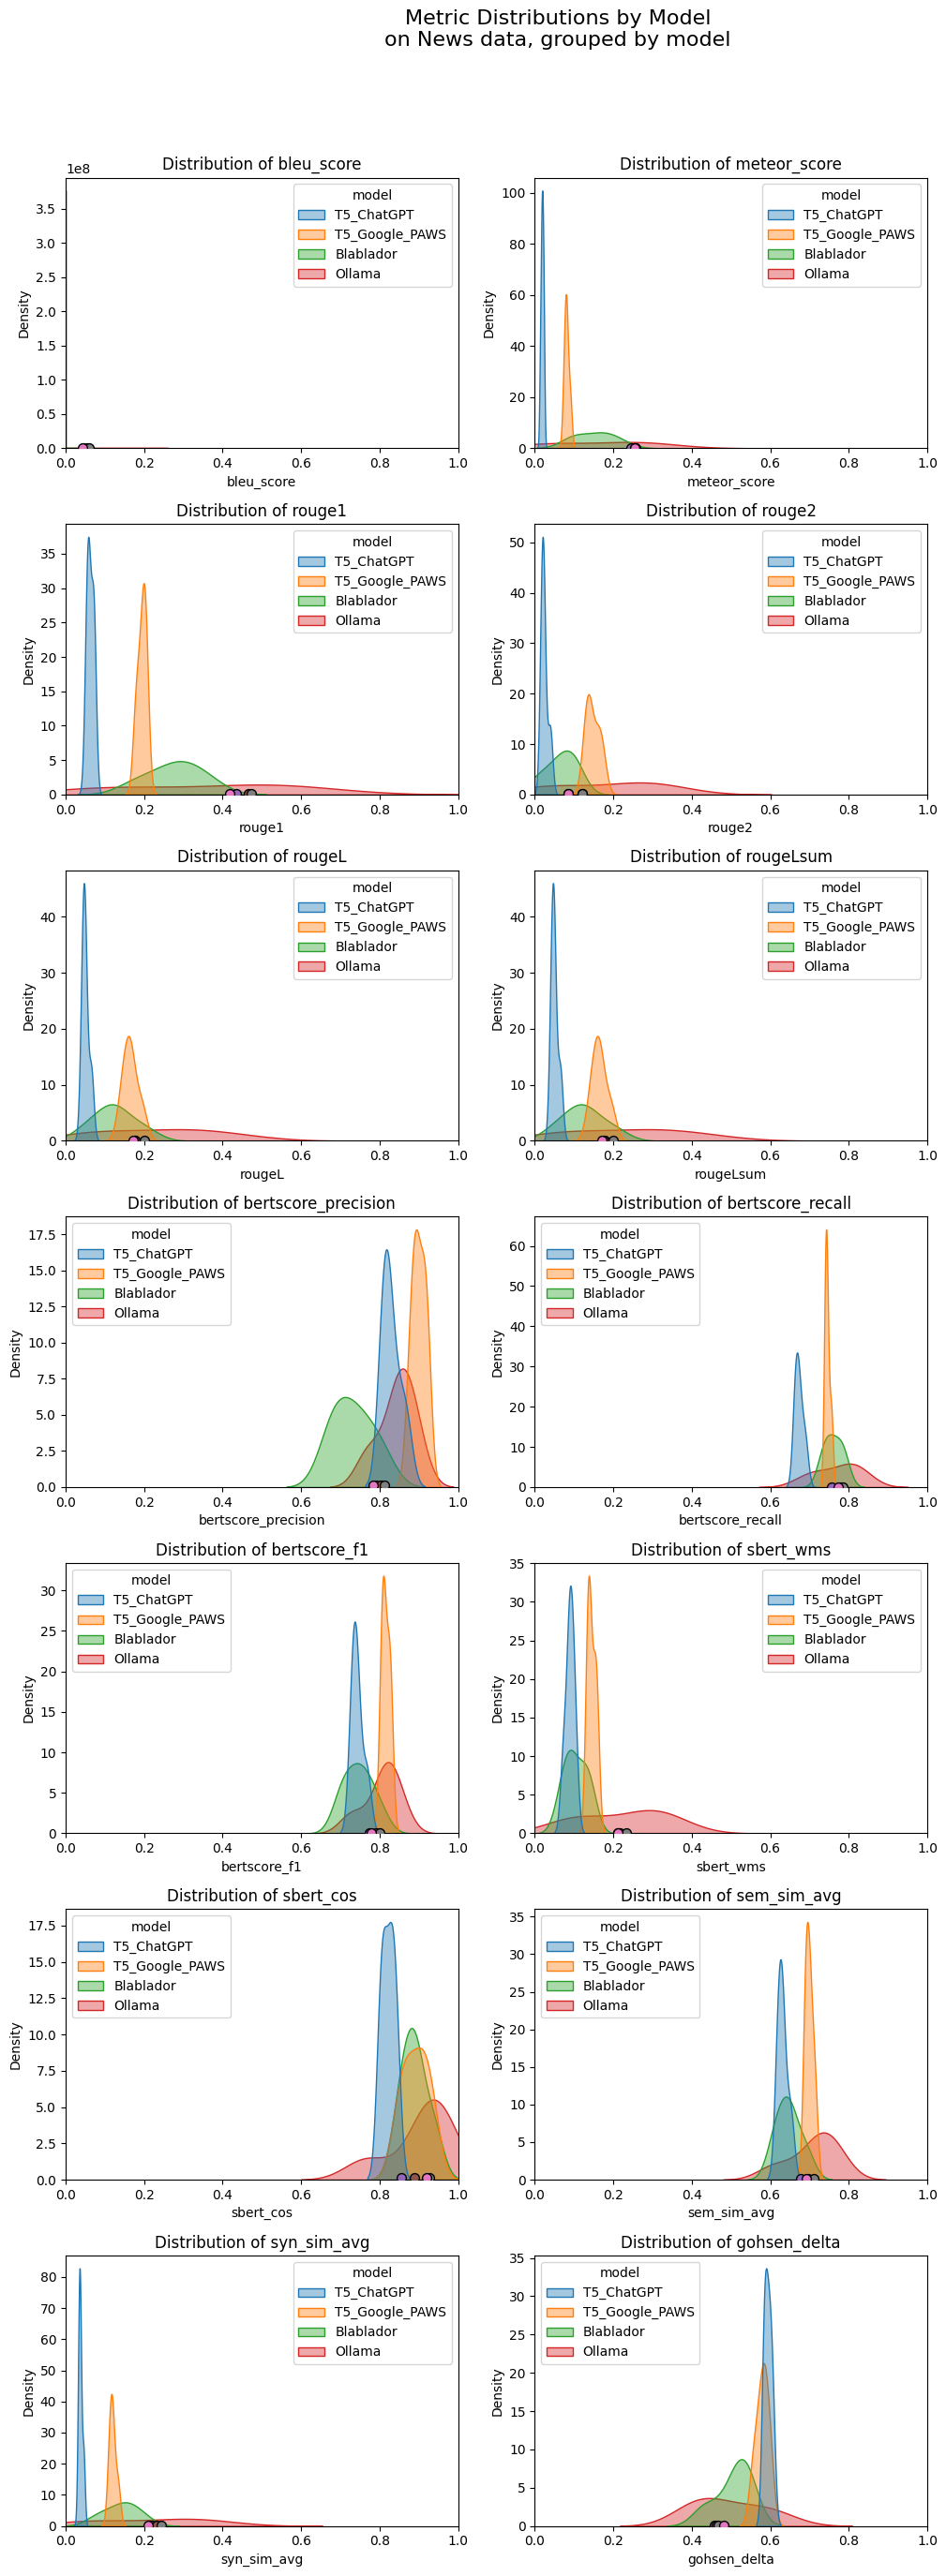

In [16]:
paraphrase_evaluator.plot_metric_distributions(df, save_path=path2results, data_category=data_category, group_by='model')

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/metric_distributions_grouped_by_prompt_20250704_202826.png


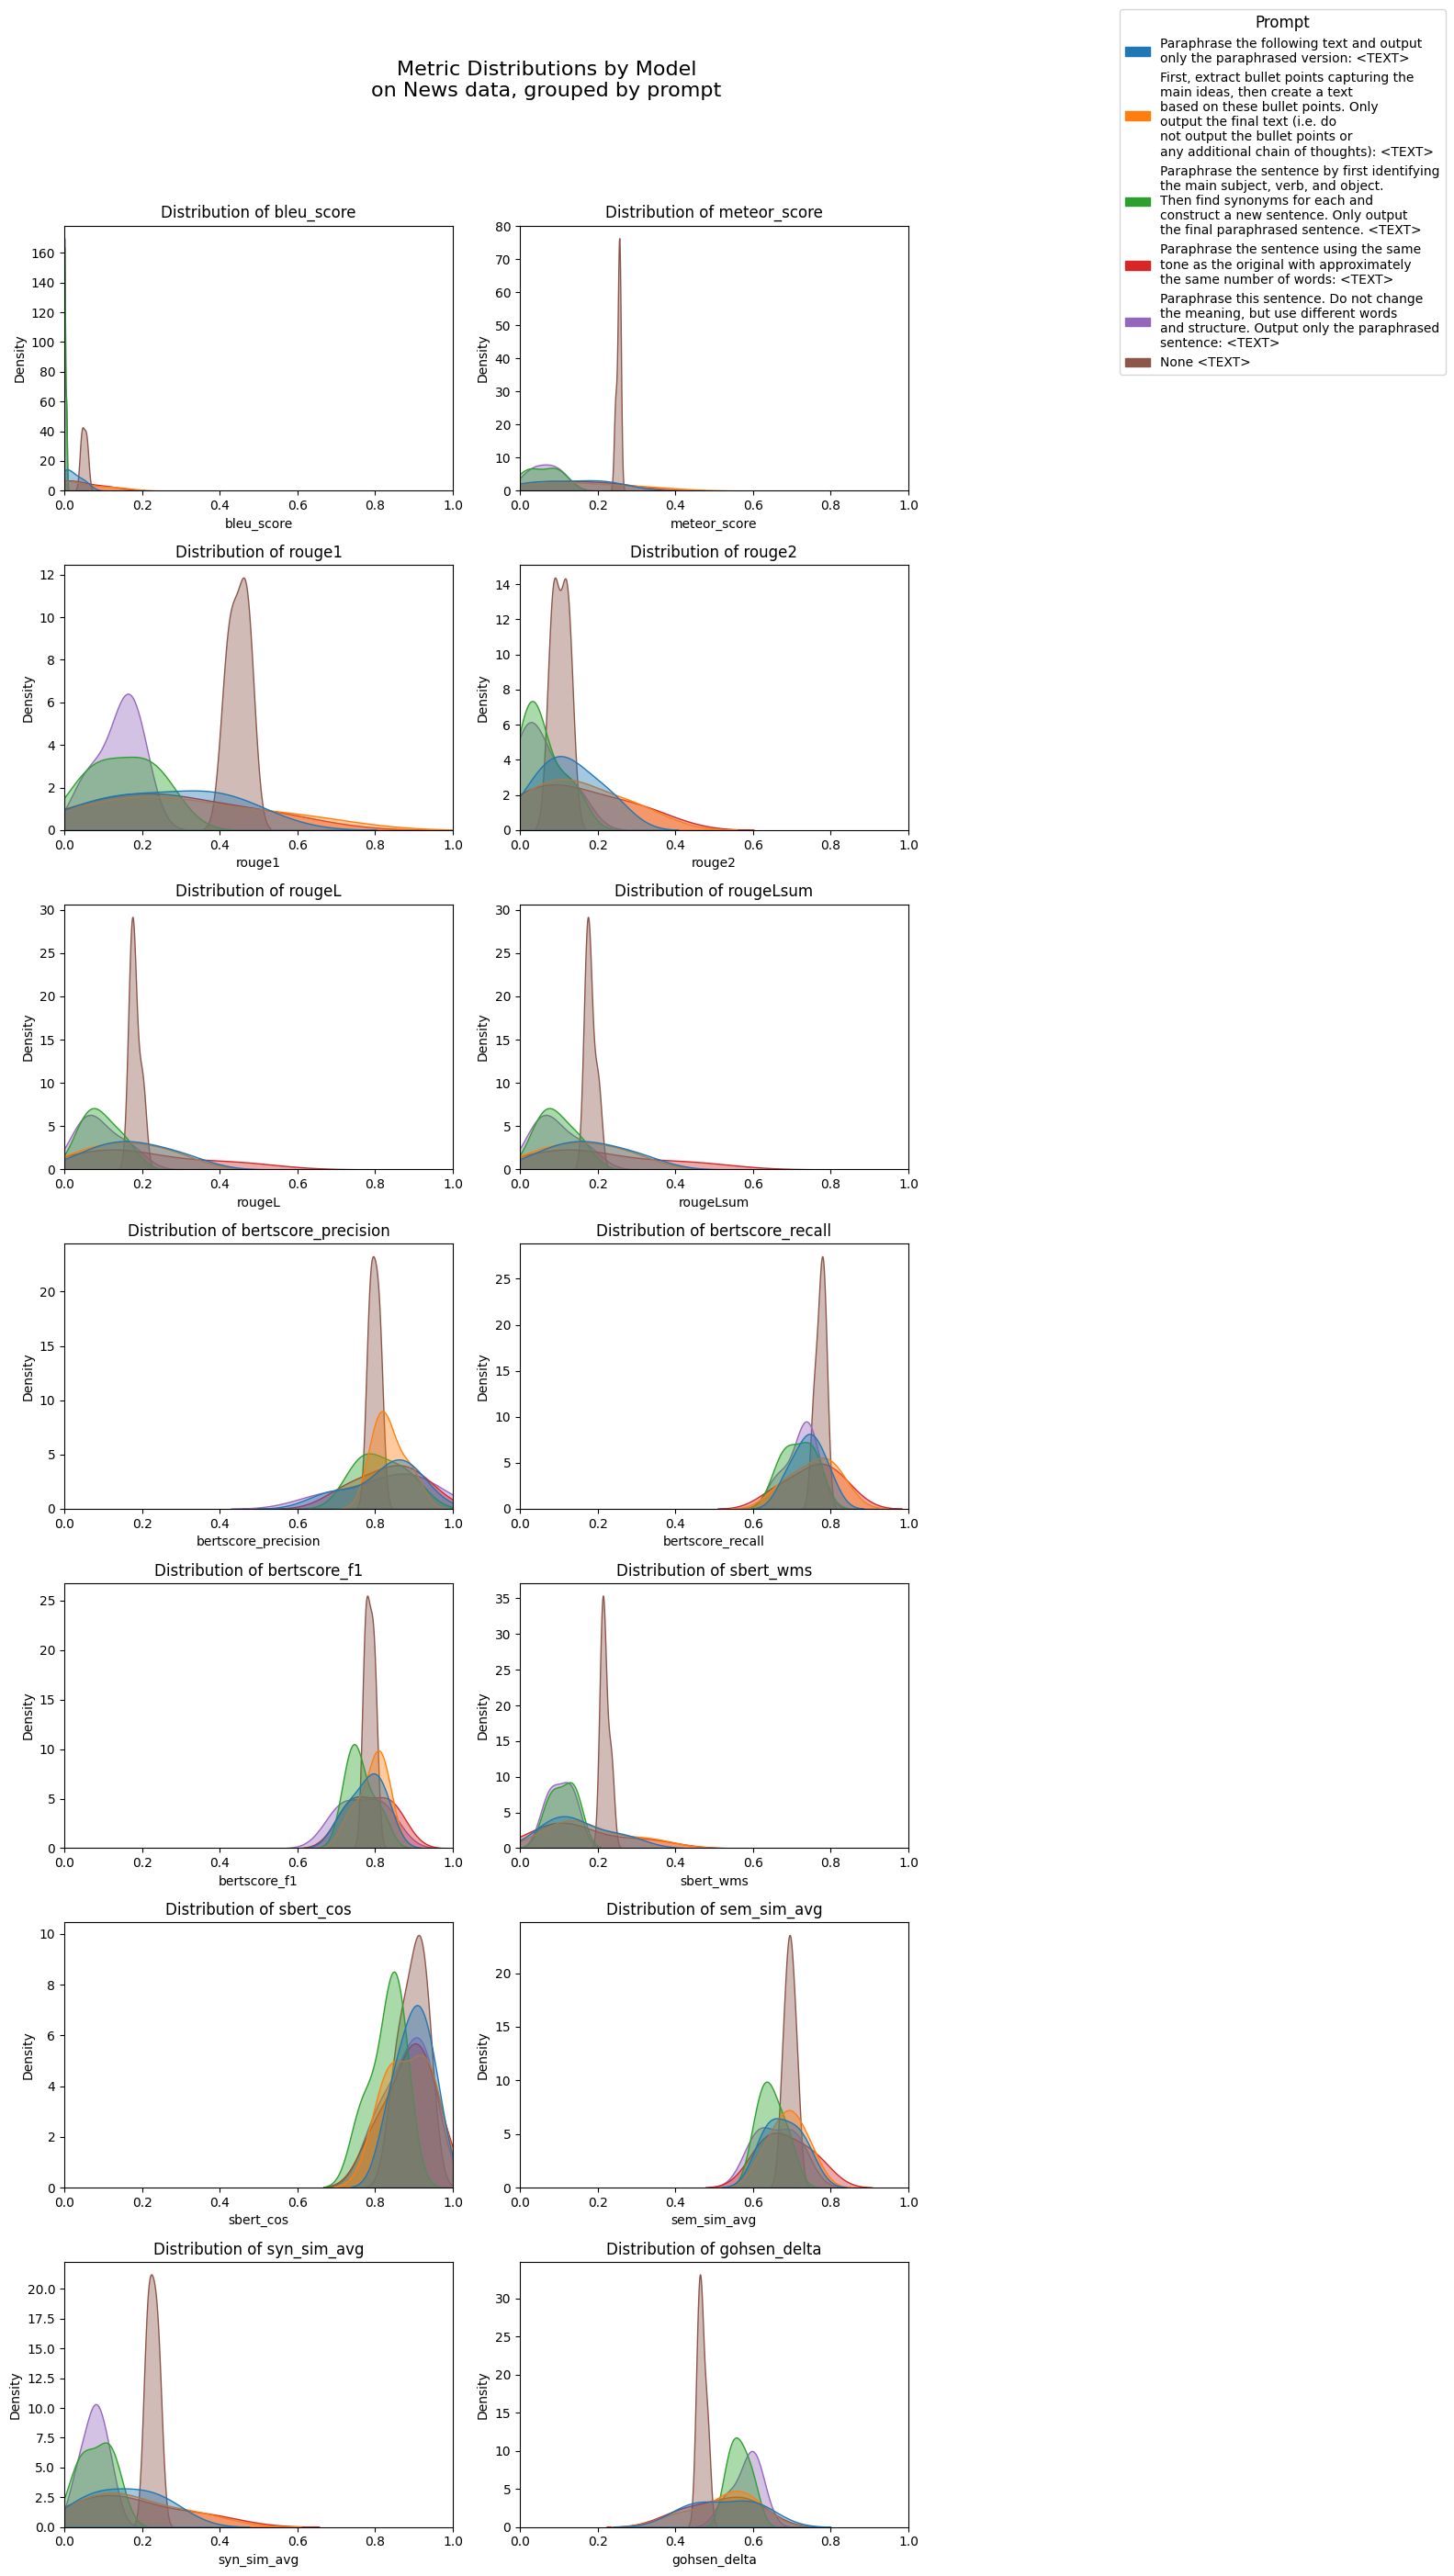

In [17]:
paraphrase_evaluator.plot_metric_distributions(df, save_path=path2results, data_category=data_category, group_by='prompt')

## Batch Processing

In [18]:
# Batch paraphrasing
# texts = ["The sky is blue.", "I love programming.", "Artificial intelligence is fascinating."]
# paraphrased_batch = bullet_point_paraphraser.paraphrase_batch(texts)
# for original, paraphrased in zip(texts, paraphrased_batch):
#     print(f"Original: {original} | Paraphrased: {paraphrased}")

In [19]:
import dirtyjson
d = dirtyjson.loads("""["foo", /* not fu*/ {bar: ['baz', null, 1.0, 2,]}] and then ignore this junk""")
d

['foo', AttributedDict([('bar', ['baz', None, 1.0, 2])])]